# Práctica guiada: Outliers y correlación entre variables

## Análisis avanzado del dataset del Titanic

En esta práctica se profundiza el análisis exploratorio del dataset del Titanic, incorporando dos herramientas fundamentales en ciencia de datos:

- La **detección de valores atípicos (outliers)**, que permite identificar observaciones que se alejan significativamente del resto de los datos.
- El análisis de **correlación entre variables**, que permite estudiar el grado de relación lineal entre variables numéricas.

**Importante:** las celdas de código de las actividades se encuentran vacías. Escriba allí las instrucciones necesarias.

**Duración estimada:** 90 minutos.

## Paso 1 — Preparar el entorno

Para esta práctica se utilizará nuevamente **Pandas** y **Matplotlib**.

```python
import pandas as pd
import matplotlib.pyplot as plt
```

**Consigna**

1. Importar las bibliotecas necesarias.
2. Cargar el archivo `Titanic.csv` en un DataFrame denominado `titanic`.
3. Mostrar las primeras filas para confirmar que el dataset se cargó correctamente.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

titanic = pd.read_csv('Titanic.csv')
# Titanic.head()
titanic[['Age']].head() 
#? Si la columna esta encerrada en [1] solo par de corchetes se muestra como serie, si esta entre [[dos]] se muestra como dataframe.
#? .head() no ordena, y puede o no tener el numero que indica cuanto.

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


## Paso 2 — Repasar las variables numéricas

El método `describe()` permite obtener un resumen estadístico de las variables numéricas de un DataFrame: cantidad de valores, media, desviación estándar, mínimo, máximo y los cuartiles.

```python
datos.describe()
```

**Consigna**

Utilizar `describe()` sobre `titanic` y observar especialmente las columnas `Age` y `Fare`.

Prestar atención a la diferencia entre el valor máximo y el percentil 75 % (`75%`) en cada columna. ¿En cuál de las dos parece haber una diferencia más notoria?

In [13]:
# titanic.describe().round(2)
titanic[['Age', 'Fare']].describe().round(2)

,Age,Fare
count,714.00,891.00
mean,29.70,32.20
std,14.53,49.69
min,0.42,0.00
25%,20.12,7.91
50%,28.00,14.45
75%,38.00,31.00
max,80.00,512.33


# Detección de valores atípicos (outliers)

Un **outlier** (o valor atípico) es una observación que se aleja considerablemente del resto de los valores de una variable.

Los outliers pueden deberse a errores de carga de datos, a casos genuinamente excepcionales, o a la naturaleza propia de la variable (por ejemplo, unos pocos pasajeros que pagaron tarifas mucho más altas que el resto).

Detectarlos es importante porque pueden afectar fuertemente medidas como la media o el desvío estándar, y también el desempeño de algunos modelos.

## Paso 3 — Visualizar outliers con un boxplot

Un **boxplot** (diagrama de caja) es una representación gráfica que resume la distribución de una variable numérica a partir de sus cuartiles.

- La **caja** representa el rango entre el primer cuartil (Q1) y el tercer cuartil (Q3).
- La línea dentro de la caja representa la **mediana**.
- Los **"bigotes"** se extienden hasta un límite calculado a partir de la dispersión de los datos.
- Los puntos que quedan **por fuera de los bigotes** se consideran posibles **outliers**.

Con Matplotlib puede construirse mediante:

```python
plt.boxplot(datos["Fare"].dropna())
plt.ylabel("Fare")
plt.title("Boxplot de Fare")
plt.show()
```

**Consigna**

Construir un boxplot de la variable `Fare`.

Observar la cantidad de puntos que aparecen por fuera de los bigotes.

Text(0.5, 1.0, 'Boxplot de Fare (Horizontal)')

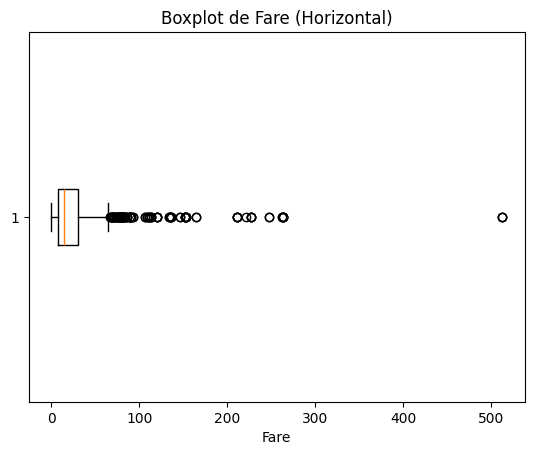

In [23]:
plt.boxplot(titanic['Fare'].dropna(), vert=False)
plt.xlabel("Fare")
plt.title("Boxplot de Fare (Horizontal)")

## Paso 4 — El método del rango intercuartílico (IQR)

Una forma habitual de definir de manera numérica qué se considera un outlier es el **método del rango intercuartílico (IQR)**.

- **Q1**: primer cuartil (percentil 25).
- **Q3**: tercer cuartil (percentil 75).
- **IQR = Q3 - Q1**.

Se consideran outliers aquellos valores que están por debajo de:

```
límite_inferior = Q1 - 1.5 * IQR
```

o por encima de:

```
límite_superior = Q3 + 1.5 * IQR
```

En Pandas, los cuartiles pueden obtenerse mediante `quantile()`:

```python
q1 = datos["Fare"].quantile(0.25)
q3 = datos["Fare"].quantile(0.75)
```

**Consigna**

Para la variable `Fare`:

1. Calcular Q1, Q3 y el IQR.
2. Calcular el límite inferior y el límite superior.
3. Mostrar ambos límites.

In [31]:
q1 = titanic['Fare'].quantile(0.25).round(2)
q3 = titanic['Fare'].quantile(0.75)
iqr = q3 - q1

print('Cuartil 1: ', q1, '\nCuartil 2: ', q3)
print('IQR: ', iqr)

Cuartil 1:  7.91 
Cuartil 2:  31.0
IQR:  23.09


In [35]:
limiteInf = q1 - 1.5 * iqr
limiteSup = q3 + 1.5 * iqr

print('Limite Inferior: ', limiteInf, '\nLimite Superior: ', limiteSup)

Limite Inferior:  -26.724999999999998 
Limite Superior:  65.63499999999999


## Paso 5 — Identificar los outliers

Una vez calculados los límites, se pueden utilizar para filtrar el DataFrame y obtener únicamente las filas consideradas outliers.

```python
outliers = datos[(datos["Fare"] < limite_inferior) | (datos["Fare"] > limite_superior)]
```

**Consigna**

1. Filtrar `titanic` para obtener las filas cuyo valor de `Fare` sea considerado un outlier según el método del IQR.
2. Determinar cuántos pasajeros son considerados outliers.
3. Calcular qué porcentaje representan sobre el total del dataset.
4. Mostrar algunas de esas filas y observar si comparten alguna característica (por ejemplo, la clase en la que viajaban).

In [46]:
outliers = titanic[(titanic['Fare'] < limiteInf) | (titanic['Fare'] > limiteSup)]
# print('Filtrados: \n', outliers)
outliersTotal = outliers['PassengerId'].count()
print('Cantidad de outliers: ', outliersTotal)

PorcTotal = outliersTotal / (titanic['PassengerId'].count())
print('Porcentaje de outliers sobre el total: ', PorcTotal.round(3), '%')


Cantidad de outliers:  116
Porcentaje de outliers sobre el total:  0.13 %


## Paso 6 — Repetir el análisis para `Age`

**Consigna**

Repetir el procedimiento del método del IQR (pasos 4 y 5), esta vez para la variable `Age`:

1. Calcular Q1, Q3, IQR y los límites.
2. Determinar cuántos pasajeros son considerados outliers según ese criterio.
3. Comparar la cantidad de outliers obtenida con la de `Fare`. ¿En qué variable hay proporcionalmente más valores atípicos?

## Paso 7 — Comparar la variable `Fare` según la clase

Los outliers no siempre representan errores: en este caso, es esperable que algunos pasajeros de primera clase hayan pagado tarifas mucho más altas que el resto.

Es posible construir varios boxplots agrupando los datos según otra variable. Por ejemplo, para comparar `Fare` según `Pclass`:

```python
datos.boxplot(column="Fare", by="Pclass")
plt.title("Fare según Pclass")
plt.suptitle("")
plt.show()
```

**Consigna**

Construir un boxplot de `Fare` agrupado por `Pclass`.

Observar si los valores atípicos identificados en el Paso 5 se concentran en alguna clase en particular.

## Paso 8 — Decidir una estrategia frente a los outliers

Detectar outliers no implica necesariamente que deban eliminarse. Según el contexto, las estrategias más habituales son:

- **Conservarlos**, si representan casos válidos y relevantes para el análisis.
- **Eliminarlos**, si se consideran errores o si distorsionan fuertemente el análisis.
- **Transformarlos**, por ejemplo aplicando una escala logarítmica, o utilizando técnicas de *capping* (limitar los valores extremos a un máximo o mínimo razonable).

**Consigna**

Teniendo en cuenta lo observado en los pasos anteriores, redactar una breve justificación (2 a 4 líneas) sobre qué estrategia aplicaría para los outliers de `Fare` en este dataset, y por qué.

# Correlación entre variables

El **coeficiente de correlación de Pearson** mide el grado de relación lineal entre dos variables numéricas. Toma valores entre -1 y 1:

- Valores cercanos a **1** indican una fuerte relación lineal **positiva** (cuando una variable aumenta, la otra también).
- Valores cercanos a **-1** indican una fuerte relación lineal **negativa** (cuando una variable aumenta, la otra disminuye).
- Valores cercanos a **0** indican poca o ninguna relación lineal.

## Paso 9 — Calcular la matriz de correlación

Pandas permite calcular la correlación entre todas las variables numéricas de un DataFrame mediante `corr()`:

```python
datos.corr(numeric_only=True)
```

**Consigna**

Calcular la matriz de correlación de las variables numéricas de `titanic`.

## Paso 10 — Interpretar la matriz de correlación

**Consigna**

A partir de la matriz obtenida en el Paso 9:

1. Identificar con qué variable `Survived` presenta la correlación más alta en valor absoluto (sin contar consigo misma).
2. Indicar si esa correlación es positiva o negativa, y qué significa en términos prácticos.
3. Identificar el par de variables (sin contar `Survived`) que presenta la correlación más fuerte entre sí.

Para responder las siguientes preguntas se necesitan algunas herramientas de Pandas que todavía no usamos. Veámoslas de a una, con un ejemplo simple.

**Seleccionar una fila o columna de la matriz**

Como `correlaciones` es un DataFrame, se puede acceder a una sola columna igual que en cualquier otro DataFrame:

```python
correlaciones["Survived"]
```

Esto devuelve una **Serie** con la correlación de `Survived` contra cada una de las demás variables (incluida ella misma, que siempre vale 1).

**Descartar un valor con `drop()`**

Como no interesa la correlación de `Survived` consigo misma, se la puede eliminar de la Serie con `drop()`, indicando la etiqueta que se quiere sacar:

```python
correlacion_survived = correlaciones["Survived"].drop("Survived")
```

**Valor absoluto con `abs()`**

Interesa la **fuerza** de la relación, sin importar si es positiva o negativa. Por eso se usa `abs()`, que devuelve el valor absoluto de cada elemento:

```python
correlacion_survived.abs()
```

Por ejemplo, si una Serie tiene los valores `-0.5` y `0.3`, al aplicar `abs()` se obtienen `0.5` y `0.3`: así, `-0.5` (una correlación negativa fuerte) puede compararse en igualdad de condiciones con una correlación positiva.

**Encontrar la etiqueta del valor máximo con `idxmax()`**

`idxmax()` no devuelve el valor más alto, sino el **nombre** (índice) donde se encuentra ese valor. Por ejemplo:

```python
import pandas as pd
serie = pd.Series([0.1, -0.6, 0.4], index=["A", "B", "C"])
serie.abs().idxmax()   # devuelve "B", porque abs(-0.6) = 0.6 es el mayor valor
```

Aplicando esta misma idea a `correlacion_survived.abs()` se obtiene el nombre de la variable más correlacionada con `Survived`.

**Comparar todos los pares de variables entre sí (punto 3)**

Para este punto ya no alcanza con una sola columna: hay que comparar **todas las variables entre sí**, excluyendo a `Survived`. Los pasos son:

1. Eliminar la fila y la columna de `Survived` de la matriz completa, usando `drop()` con `index` y `columns`:

```python
correlaciones_sin_survived = correlaciones.drop(index="Survived", columns="Survived")
```

2. Aplicar `abs()` a toda la matriz (funciona igual que sobre una Serie, pero sobre todos los valores del DataFrame).

3. La diagonal de la matriz (la correlación de cada variable consigo misma) siempre vale 1, y no debe considerarse como resultado. Se puede "borrar" reemplazándola por 0, usando `np.fill_diagonal()` (de la biblioteca `numpy`):

```python
import numpy as np
np.fill_diagonal(correlaciones_sin_survived_abs.values, 0)
```

4. Por último, `stack()` transforma la matriz (filas × columnas) en una única Serie, donde cada valor queda identificado por el **par de variables** (fila, columna) al que corresponde:

```python
correlaciones_sin_survived_abs.stack()
```

Sobre esa Serie de pares ya se puede aplicar `idxmax()`, tal como se hizo en el punto 1, para obtener el par de variables con la correlación más fuerte.

## Paso 11 — Visualizar la matriz con un mapa de calor

Un **mapa de calor (heatmap)** permite representar visualmente una matriz de valores utilizando colores, lo que facilita identificar rápidamente las correlaciones más fuertes.

Con Matplotlib puede construirse a partir de la matriz de correlación mediante `imshow()`:

```python
correlaciones = datos.corr(numeric_only=True)

plt.imshow(correlaciones, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(correlaciones.columns)), correlaciones.columns, rotation=90)
plt.yticks(range(len(correlaciones.columns)), correlaciones.columns)
plt.title("Matriz de correlación")
plt.show()
```

**Consigna**

Construir un mapa de calor de la matriz de correlación calculada en el Paso 9.

## Paso 12 — Correlación no implica causalidad

**Consigna**

A partir de la correlación identificada entre `Pclass` y `Fare` (o entre `Pclass` y `Survived`), reflexionar y responder:

1. ¿Qué significa, en términos generales, que dos variables estén correlacionadas?
2. ¿Por qué encontrar una correlación entre dos variables no permite afirmar que una sea la causa de la otra?
3. Proponer un ejemplo (puede estar relacionado con el Titanic o no) en el que dos variables estén correlacionadas sin que exista una relación de causa y efecto entre ellas.

# Actividad integradora

Utilizando el dataset del Titanic, realizar un análisis que integre los conceptos trabajados en esta práctica.

El análisis debe incluir:

1. Detección de outliers en `Fare` utilizando el método del IQR.
2. Una estrategia justificada para tratar esos outliers (eliminarlos, transformarlos o conservarlos).
3. Cálculo de la matriz de correlación **antes** de aplicar esa estrategia.
4. Cálculo de la matriz de correlación **después** de aplicar esa estrategia.
5. Una comparación entre ambas matrices: ¿cambiaron significativamente las correlaciones al tratar los outliers?

## Pregunta final

A partir de los resultados obtenidos, responder:

> **¿El tratamiento de los outliers modificó de forma relevante las relaciones observadas entre las variables? ¿Por qué creé que ocurrió (o no) ese efecto?**

La respuesta debe estar fundamentada en los resultados obtenidos mediante Pandas.